# 🦅 Optimasi Rantai Pasok Dingin Menggunakan Aquila Optimizer (AO)

Notebook ini memformulasikan model rantai pasok dingin (cold chain) untuk pengiriman komoditas peka suhu (seperti vaksin medis sensitif atau bahan pangan segar). Kami mendefinisikan laju penurunan kualitas komoditas menggunakan **Persamaan Kinetika Arrhenius** dan menghitung biaya refrigerasi fisik.

Kami mengimplementasikan **Aquila Optimizer (AO)** dari nol untuk mencari proporsi alokasi moda logistik optimal harian ($x = [x_{\text{standard}}, x_{\text{second}}, x_{\text{first}}, x_{\text{same\_day}}]$) yang meminimalkan total biaya (biaya transportasi + biaya energi refrigerasi) di bawah batasan kualitas tiba produk aman ($\ge 85\%$).

## 1. Formulasi Matematika Rantai Pasok Dingin

### A. Penurunan Kualitas Komoditas (Arrhenius Orde Kesatu)
Kualitas komoditas peka suhu saat tiba di tujuan dihitung sebagai:
$$Q = Q_0 \cdot e^{-k(T) \cdot t}$$
Konstanta laju pembusukan $k(T)$ berbasis suhu kontainer pendingin mengikuti hukum Arrhenius:
$$k(T) = A \cdot e^{-\frac{E_a}{R \cdot T}}$$

### B. Konsumsi Energi Refrigerasi Kontainer
Biaya refrigerasi sebanding dengan perbedaan suhu luar (ambient) dengan suhu kontainer pengiriman, dikalikan dengan waktu tempuh:
$$C_{refrig} = P_{energy} \cdot \max(0, T_{ambient} - T_{container}) \cdot t$$

### C. Fungsi Kebugaran (Fitness Function) Harian
Optimasi harian bertujuan meminimalkan biaya logistik total:
$$TC = \sum_{m=1}^{4} x_m \cdot D \cdot (C_{trans, m} + C_{refrig, m}) + \text{Penalty}(Q)$$
Dengan batasan (*constraints*):
*   $\sum_{m=1}^4 x_m = 1$ (proporsi alokasi moda pengiriman, $x_m \ge 0$)
*   Kapasitas operasional: $x_{\text{standard}} \ge 0.20$, $x_{\text{second}} \le 0.40$, $x_{\text{first}} \le 0.30$, $x_{\text{same\_day}} \le 0.15$
*   Standar kualitas tiba minimum: $\sum_{m=1}^4 x_m \cdot Q_m \ge 85.0\%$

## 2. Impor Pustaka & Setup Parameter Fisik

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (13, 6)

# Parameter Arrhenius Kualitas Produk
Q0 = 100.0
Ea = 60000.0
A_decay = 8e9
R_gas = 8.314

# Properti Moda Pengiriman
times = np.array([4.0, 2.0, 1.0, 0.5])
T_container_C = np.array([8.0, 4.0, 2.0, 1.0])
T_container_K = T_container_C + 273.15
c_trans = np.array([1.5, 3.0, 6.0, 12.0])

P_energy = 0.015

# Batasan Kapasitas (Constraints)
min_capacity = np.array([0.20, 0.0, 0.0, 0.0])
max_capacity = np.array([1.0, 0.40, 0.30, 0.15])
min_avg_quality = 85.0

# Hitung Kualitas Tiba
k_decay = A_decay * np.exp(-Ea / (R_gas * T_container_K))
Q_arrival = Q0 * np.exp(-k_decay * times)

print("Laju kerusakan per hari (k):", k_decay)
print("Kualitas produk saat tiba (%):", Q_arrival)

Laju kerusakan per hari (k): [0.05692906 0.03930454 0.03252691 0.02955923]
Kualitas produk saat tiba (%): [79.63502032 92.44012229 96.79963988 98.53290665]


## 3. Fitness Function dengan Metode Penalti

In [2]:
def compute_fitness(x, demand, ambient_temp):
    x = np.abs(x)
    sum_x = np.sum(x)
    if sum_x == 0:
        x = np.ones(len(x)) / len(x)
    else:
        x = x / sum_x
        
    # 1. Biaya Transportasi
    cost_trans = demand * np.sum(x * c_trans)
    
    # 2. Biaya Energi Pendinginan
    temp_diff = np.clip(ambient_temp - T_container_C, a_min=0.0, a_max=None)
    cost_refrig = demand * np.sum(x * P_energy * temp_diff * times)
    
    # 3. Kualitas Tiba
    avg_quality = np.sum(x * Q_arrival)
    
    # Penalti
    penalty = 0.0
    for i in range(len(x)):
        if x[i] > max_capacity[i]:
            penalty += (x[i] - max_capacity[i]) ** 2 * 50000.0
        if x[i] < min_capacity[i]:
            penalty += (min_capacity[i] - x[i]) ** 2 * 50000.0
            
    if avg_quality < min_avg_quality:
        penalty += (min_avg_quality - avg_quality) ** 2 * 50000.0
        
    total_fitness = cost_trans + cost_refrig + penalty
    return total_fitness, cost_trans, cost_refrig, x, avg_quality

## 4. Implementasi Aquila Optimizer (AO) dari Nol

In [3]:
def levy_flight(dim):
    beta = 1.5
    sigma = (math.gamma(1 + beta) * math.sin(math.pi * beta / 2) / 
             (math.gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2)))**(1.0 / beta)
    u = np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    step = u / (np.abs(v)**(1.0 / beta))
    return step

def run_aquila_optimizer(demand, ambient_temp, max_iter=100, pop_size=40, dim=4, lb=0.0, ub=1.0):
    X = np.random.uniform(lb, ub, (pop_size, dim))
    best_X = np.zeros(dim)
    best_fitness = float('inf')
    
    alpha = 0.1
    delta = 0.1
    
    for t in range(max_iter):
        X_mean = np.mean(X, axis=0)
        
        for i in range(pop_size):
            fit = compute_fitness(X[i], demand, ambient_temp)[0]
            if fit < best_fitness:
                best_fitness = fit
                best_X = X[i].copy()
                
        for i in range(pop_size):
            r1 = np.random.rand()
            if t <= (2.0 / 3.0) * max_iter:
                if np.random.rand() < 0.5:
                    X[i] = best_X * (1.0 - t / max_iter) + (X_mean - best_X) * np.random.rand()
                else:
                    X[i] = best_X * levy_flight(dim) + X[i] + (np.random.rand() * (ub - lb) + lb)
            else:
                if np.random.rand() < 0.5:
                    X[i] = (best_X - X_mean) * alpha - np.random.rand() + ((ub - lb) * np.random.rand() + lb) * delta
                else:
                    QF = t ** ((2.0 * np.random.rand() - 1.0) / (1.0 - max_iter)**2)
                    G1 = 2.0 * np.random.rand() - 1.0
                    G2 = 2.0 * (1.0 - t / max_iter)
                    X[i] = QF * best_X - (G1 * X[i] * np.random.rand()) - G2 * levy_flight(dim) + np.random.rand() * G1
            
            X[i] = np.clip(X[i], lb, ub)
            
    _, cost_trans_opt, cost_refrig_opt, final_x, avg_q = compute_fitness(best_X, demand, ambient_temp)
    return final_x, cost_trans_opt, cost_refrig_opt, avg_q

## 5. Memuat Prediksi Permintaan & Optimasi Dinamis

In [4]:
pred_path = 'data/predicted/daily_predictions.csv'
df_pred = pd.read_csv(pred_path)
print(f"Memuat {len(df_pred)} hari hasil prediksi GRU...")

opt_results = []
for idx, row in df_pred.iterrows():
    date = row['date']
    demand = row['predicted_demand']
    temp = row['ambient_temp']
    
    final_x, trans, refrig, avg_q = run_aquila_optimizer(demand, temp, max_iter=100, pop_size=40)
    
    opt_results.append({
        'date': pd.to_datetime(date),
        'demand_predicted': demand,
        'ambient_temp': temp,
        'x_standard': final_x[0],
        'x_second': final_x[1],
        'x_first': final_x[2],
        'x_same_day': final_x[3],
        'cost_trans': trans,
        'cost_refrig': refrig,
        'total_cost_opt': trans + refrig,
        'avg_quality_opt': avg_q
    })

df_opt = pd.DataFrame(opt_results)
df_opt.set_index('date', inplace=True)

out_dir = 'data/optimization'
os.makedirs(out_dir, exist_ok=True)
df_opt.to_csv(os.path.join(out_dir, 'optimization_results.csv'))
print(f"Optimasi selesai dan disimpan ke {out_dir}/optimization_results.csv")

Memuat 57 hari hasil prediksi GRU...


Optimasi selesai dan disimpan ke data/optimization/optimization_results.csv


## 6. Visualisasi Proporsi Alokasi Dinamis

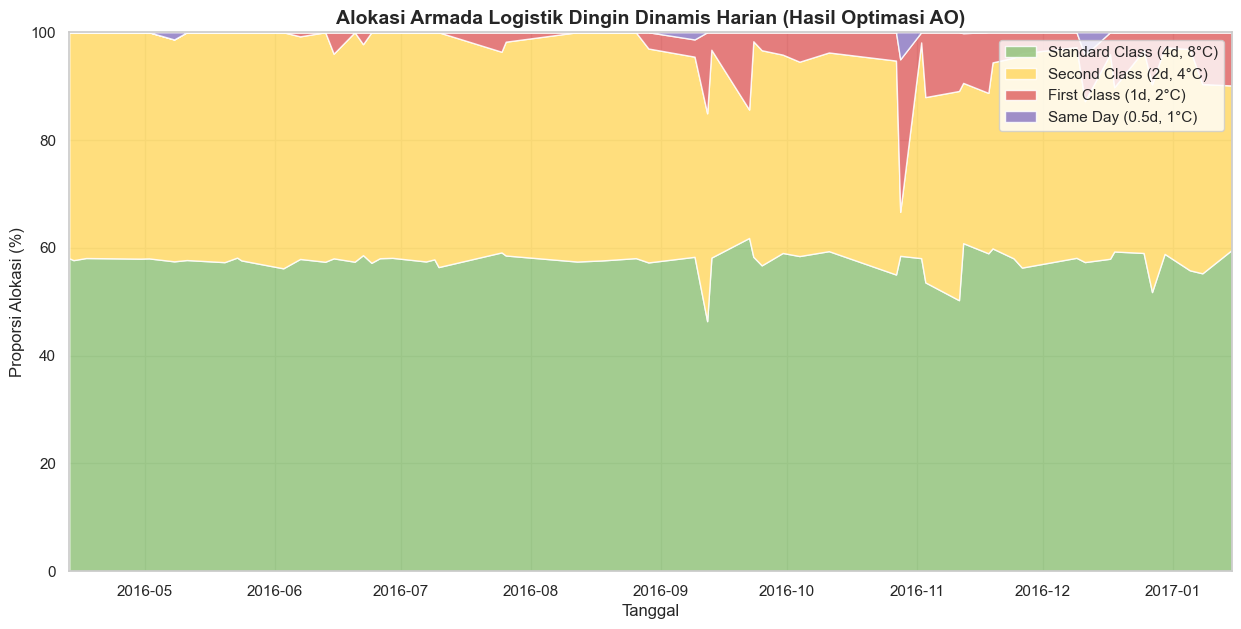

In [5]:
modes = ['x_standard', 'x_second', 'x_first', 'x_same_day']
mode_labels = [
    'Standard Class (4d, 8°C)', 
    'Second Class (2d, 4°C)', 
    'First Class (1d, 2°C)', 
    'Same Day (0.5d, 1°C)'
]

plt.figure(figsize=(15, 7))
plt.stackplot(
    df_opt.index, 
    df_opt['x_standard'] * 100.0,
    df_opt['x_second'] * 100.0,
    df_opt['x_first'] * 100.0,
    df_opt['x_same_day'] * 100.0,
    labels=mode_labels,
    colors=['#93c47d', '#ffd966', '#e06666', '#8e7cc3'],
    alpha=0.85
)

plt.title('Alokasi Armada Logistik Dingin Dinamis Harian (Hasil Optimasi AO)', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Proporsi Alokasi (%)')
plt.legend(loc='upper right')
plt.xlim(df_opt.index.min(), df_opt.index.max())
plt.ylim(0, 100)
plt.show()

## 7. Korelasi Suhu Ambient vs Pengiriman Ekspres

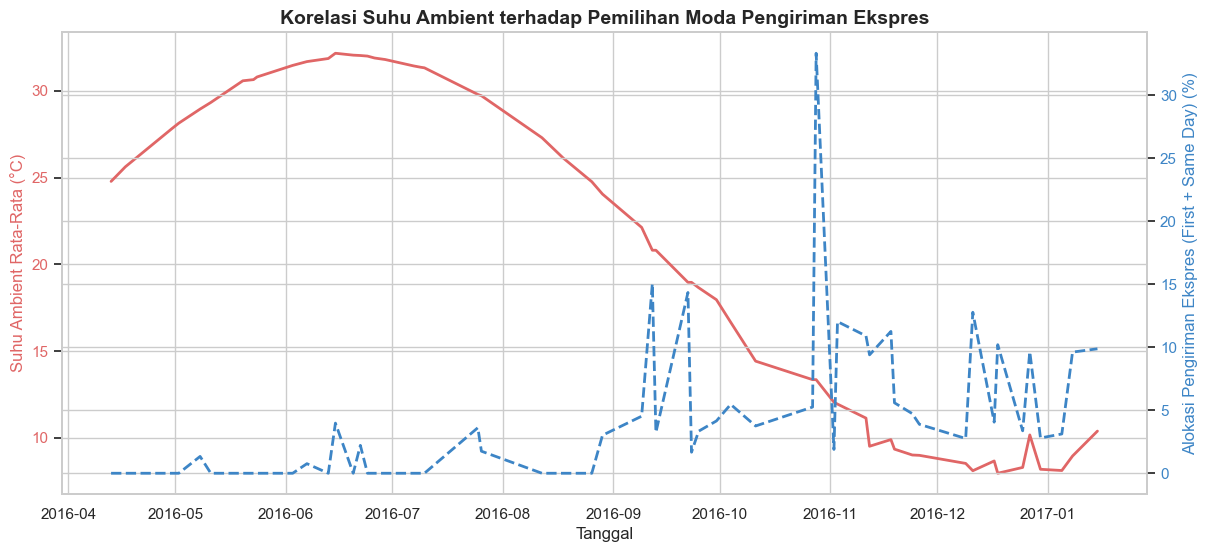

In [6]:
fig, ax1 = plt.subplots(figsize=(14, 6))

color = '#e06666'
ax1.set_xlabel('Tanggal')
ax1.set_ylabel('Suhu Ambient Rata-Rata (°C)', color=color)
ax1.plot(df_opt.index, df_opt['ambient_temp'], color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#3d85c6'
ax2.set_ylabel('Alokasi Pengiriman Ekspres (First + Same Day) (%)', color=color)
express = (df_opt['x_first'] + df_opt['x_same_day']) * 100.0
ax2.plot(df_opt.index, express, color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Korelasi Suhu Ambient terhadap Pemilihan Moda Pengiriman Ekspres', fontsize=14, fontweight='bold')
plt.show()

## 8. Verifikasi Kualitas Produk Tiba di Tujuan

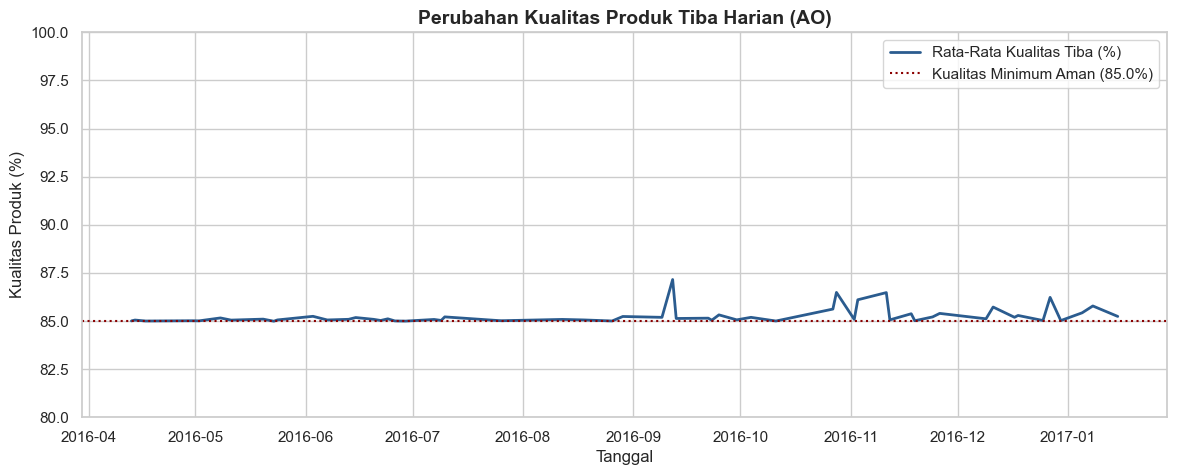

Minimum Kualitas Tiba: 84.99%
Rata-Rata Kualitas Tiba: 85.26%


In [7]:
plt.figure(figsize=(14, 5))
plt.plot(df_opt.index, df_opt['avg_quality_opt'], color='#2b5c8f', linewidth=2, label='Rata-Rata Kualitas Tiba (%)')
plt.axhline(85.0, color='darkred', linestyle=':', label='Kualitas Minimum Aman (85.0%)')
plt.title('Perubahan Kualitas Produk Tiba Harian (AO)', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Kualitas Produk (%)')
plt.ylim(80, 100)
plt.legend()
plt.show()

print(f"Minimum Kualitas Tiba: {df_opt['avg_quality_opt'].min():.2f}%")
print(f"Rata-Rata Kualitas Tiba: {df_opt['avg_quality_opt'].mean():.2f}%")